# **LIBRARY**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #visualisasi dta

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle #Loop berulang (biasanya untuk warna ROC multiclass)

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("/content/HepatitisCdata.csv", delimiter=';')
df.rename(columns={"Category": "Label"}, inplace=True)

# **DATA SEBELUM PREPRO**

In [40]:
from collections import Counter # menghitung jumlah kemunculan tiap kelas/label

print("=== JUMLAH DATA SEBELUM PREPROCESSING ===")
print(f"Jumlah baris (data): {df.shape[0]}")
print(f"Jumlah kolom (fitur): {df.shape[1]}")

print("\nDistribusi Label Awal:")
print(Counter(df['Label']))

=== JUMLAH DATA SEBELUM PREPROCESSING ===
Jumlah baris (data): 608
Jumlah kolom (fitur): 13

Distribusi Label Awal:
Counter({0: 533, 3: 30, 1: 24, 2: 21})


In [8]:
df.head()

,Unnamed: 0,Label,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Label       615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [10]:
df.describe()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000
mean,308.000000,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137
std,177.679487,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636
min,1.000000,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000
50%,308.000000,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,461.500000,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000
max,615.000000,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


# **JUMLAH MISSING VALUE**

In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
Label,0
Age,0
Sex,0
ALB,1
ALP,18
ALT,1
AST,0
BIL,0
CHE,0


In [12]:
# Map target labels
label_map = {
    '0=Blood Donor': 0,
    '0s=suspect Blood Donor': 1,
    '1=Hepatitis': 2,
    '2=Fibrosis': 3,
    '3=Cirrhosis': 4
}
df['Label'] = df['Label'].map(label_map)
df = df[df['Label'] != 1]  # drop 0s suspect blood donor


In [13]:
# Re-encode labels (0,2,3,4 → 0,1,2,3)
label_reencoder = LabelEncoder()
df['Label'] = label_reencoder.fit_transform(df['Label'])

DATA SEX SEBELUM ENCODING

In [14]:
print("=== Sebelum Encoding ===")
print(df[['Sex']].head())

=== Sebelum Encoding ===
  Sex
0   m
1   m
2   m
3   m
4   m


In [15]:
# Encode categorical column
df['Sex'] = LabelEncoder().fit_transform(df['Sex'].astype(str))
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

DATA SEX SETELAH ENCODING

In [16]:
print("\n=== Setelah Encoding ===")
print(df[['Sex']].head())


=== Setelah Encoding ===
   Sex
0    1
1    1
2    1
3    1
4    1


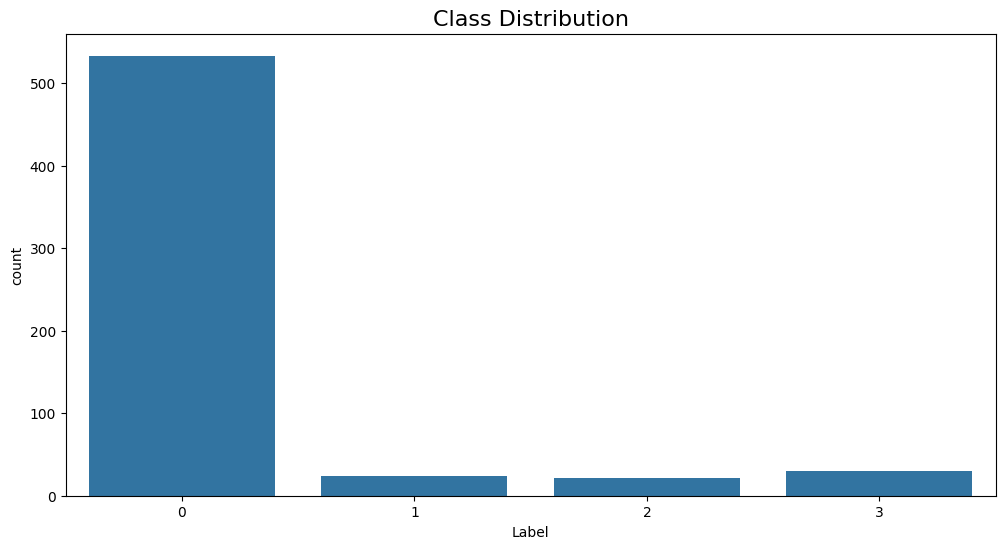

In [17]:

plt.figure(figsize=(12, 6)) #width=12, height=6

sns.countplot(x=df["Label"]) # Create countplot

plt.title("Class Distribution", fontsize=16)

plt.show()


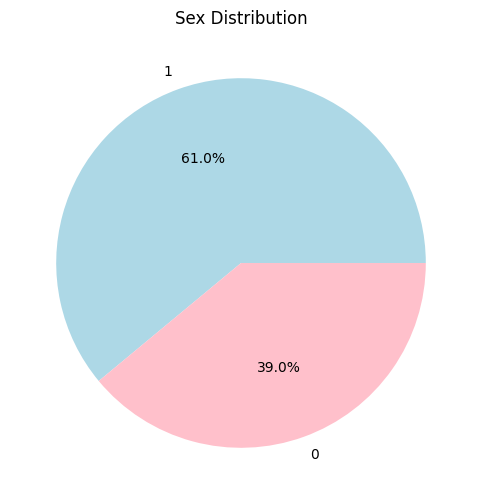

In [18]:
plt.figure(figsize=(6,6))
df["Sex"].value_counts().plot.pie(autopct="%1.1f%%", colors=["lightblue", "pink"])
plt.title("Sex Distribution")
plt.ylabel("")  # Remove y-label
plt.show()


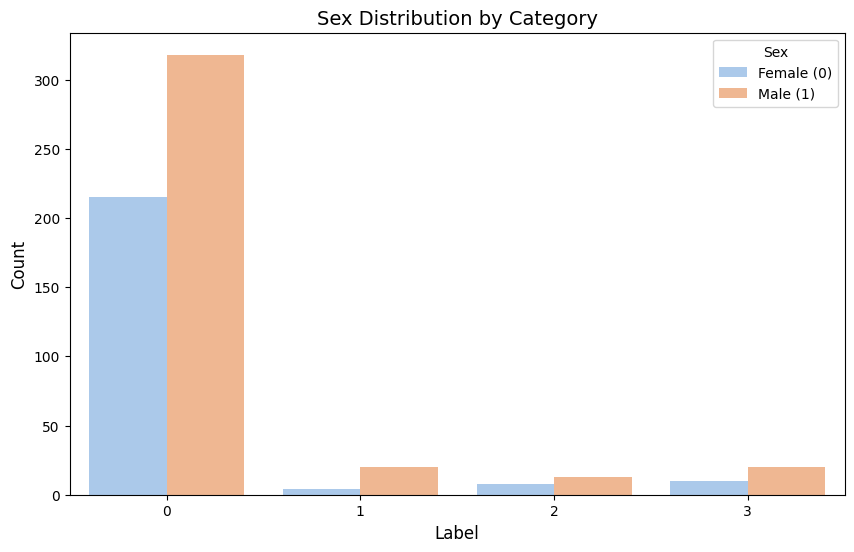

In [19]:

# Set figure size
plt.figure(figsize=(10, 6))

# Create countplot for Sex distribution grouped by Category
sns.countplot(x=df["Label"], hue=df["Sex"], palette="pastel")

plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Sex Distribution by Category", fontsize=14)
plt.legend(title="Sex", labels=["Female (0)", "Male (1)"])

plt.show()


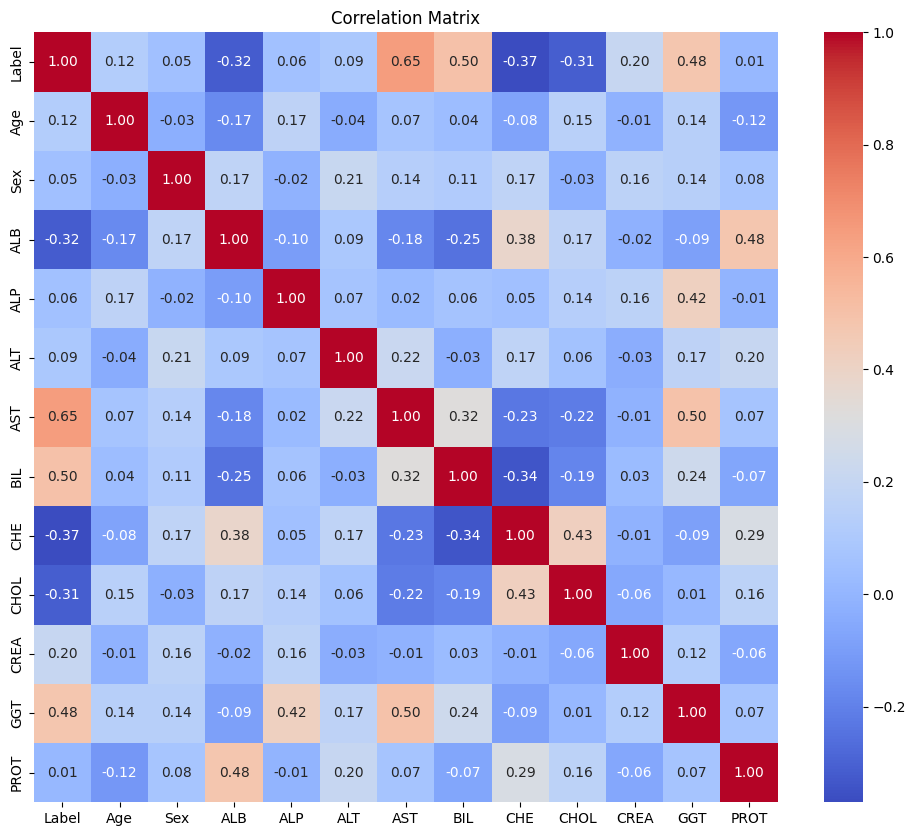

In [20]:
# Setelah data selesai diproses dan sebelum split
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# **DATA SETELAH PREPRO**

In [21]:
from collections import Counter #menghitung jumlah tiap label

# Define X and y here to resolve NameError
X = df.drop(columns='Label')
y = df['Label']

print("=== CEK JUMLAH DATA SETELAH PREPROCESSING ===")

# Jumlah baris dan kolom dataset setelah preprocessing
print(f"Jumlah baris (data): {X.shape[0]}")
print(f"Jumlah kolom (fitur): {X.shape[1]}")
print(f"Jumlah target (label): {len(y)}")

# mastiin jumlah X dan y sama
if X.shape[0] == len(y):
    print("Jumlah baris pada X dan y sama.")
else:
    print("Jumlah baris pada X dan y TIDAK sama, kemungkinan ada data yang terhapus.")

print("\nDistribusi Label:")
print(Counter(y))

=== CEK JUMLAH DATA SETELAH PREPROCESSING ===
Jumlah baris (data): 608
Jumlah kolom (fitur): 12
Jumlah target (label): 608
Jumlah baris pada X dan y sama.

Distribusi Label:
Counter({0: 533, 3: 30, 1: 24, 2: 21})


# **DATA SETELAH SPLIT**

In [22]:
# Split X and y
X = df.drop(columns='Label')
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [23]:
import pandas as pd

summary_split = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Jumlah Data': [len(X_train), len(X_test)]
})

print("\n=== Ringkasan Jumlah Data Train-Test ===")
display(summary_split)



=== Ringkasan Jumlah Data Train-Test ===


,Dataset,Jumlah Data
0,Train,486
1,Test,122


In [24]:
# Mengambil nilai label unik pada y_test,
#lalu mengurutkannya dari kecil ke besar.
updated_classes = sorted(y_test.unique())

In [25]:
# Evaluation Function
def evaluate_model(name, model, X_test, y_test, updated_classes):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) #probabilitas prediksi tiap kelas.

    print(f"\\n==== {name} ====")
    print(classification_report(y_test, y_pred))

    y_test_bin = label_binarize(y_test, classes=updated_classes)
    #cek apakah jumlah kelas probabilitas sesuai dengan jumlah kelas aktual
    if y_prob.shape[1] != len(updated_classes):
        roc_auc = np.nan
        print("Warning: ROC AUC not calculated.")
    else:
        roc_auc = roc_auc_score(y_test_bin, y_prob, average="macro")
        print("ROC AUC (macro):", roc_auc)

    #Mengembalikan hasil evaluasi dalam bentuk dictionary
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1': f1_score(y_test, y_pred, average='macro'),
        'ROC AUC': roc_auc
    }

results = []

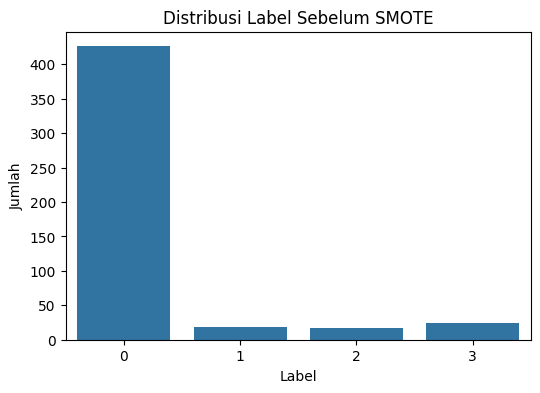

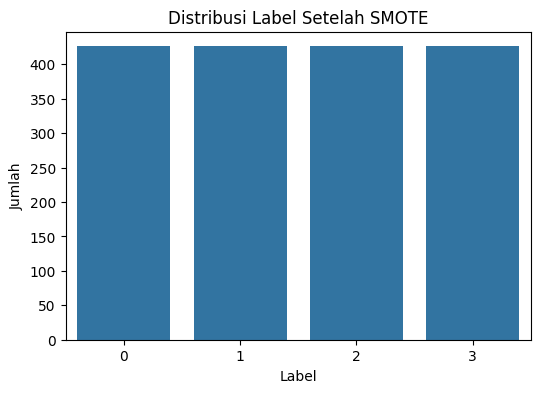

In [26]:

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Distribusi Label Sebelum SMOTE")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# SMOTE secara manual untuk visualisasi
X_temp = KNNImputer(n_neighbors=5).fit_transform(X_train)
X_temp = StandardScaler().fit_transform(X_temp) #biar fitur berskala sama
X_resampled, y_resampled = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_temp, y_train)

# Visualisasi distribusi label setelah SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title("Distribusi Label Setelah SMOTE")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()


**JUMLAH DATA SEBELUM DAN SESUDAH SMOTE**

In [27]:
from collections import Counter

# Sebelum SMOTE
print("Distribusi Label Sebelum SMOTE:")
print(Counter(y_train))
print(f"Total Data Sebelum SMOTE: {len(y_train)}\n")

# Setelah SMOTE
print("Distribusi Label Setelah SMOTE:")
print(Counter(y_resampled))
print(f"Total Data Setelah SMOTE: {len(y_resampled)}")


Distribusi Label Sebelum SMOTE:
Counter({0: 426, 3: 24, 1: 19, 2: 17})
Total Data Sebelum SMOTE: 486

Distribusi Label Setelah SMOTE:
Counter({0: 426, 1: 426, 3: 426, 2: 426})
Total Data Setelah SMOTE: 1704


In [28]:
import pandas as pd

# DataFrame perbandingan
df_dist = pd.DataFrame({
    "Sebelum SMOTE": pd.Series(Counter(y_train)),
    "Sesudah SMOTE": pd.Series(Counter(y_resampled))
}).fillna(0).astype(int)

print(df_dist)


   Sebelum SMOTE  Sesudah SMOTE
0            426            426
1             19            426
3             24            426
2             17            426


In [29]:
#Model 1: XGBoost Baseline
baseline_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])
baseline_pipeline.fit(X_train, y_train)
results.append(evaluate_model("XGBoost Base", baseline_pipeline, X_test, y_test, updated_classes))




\n==== XGBoost Base ====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       107
           1       0.50      0.40      0.44         5
           2       0.60      0.75      0.67         4
           3       0.83      0.83      0.83         6

    accuracy                           0.95       122
   macro avg       0.73      0.74      0.73       122
weighted avg       0.95      0.95      0.95       122

ROC AUC (macro): 0.969548524115933


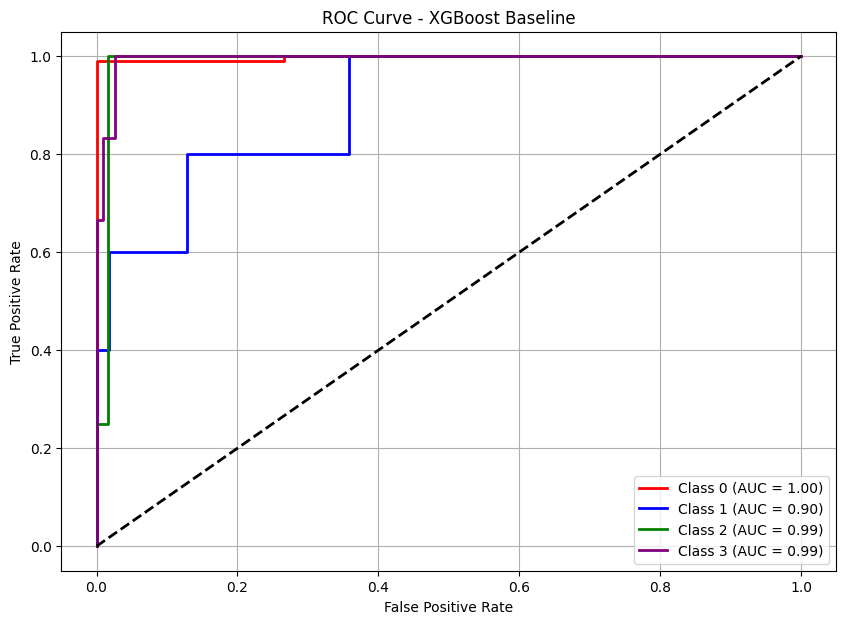

In [30]:
# Prediksi probabilitas
y_score = baseline_pipeline.predict_proba(X_test)

# Binarisasi label
y_test_bin = label_binarize(y_test, classes=updated_classes)
n_classes = y_test_bin.shape[1]

# Hitung ROC dan AUC tiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    #Menghitung FP Rate dan TP Rate kelas ke-i
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    #Menghitung nilai AUC untuk kelas ke-i
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
colors = cycle(['red', 'blue', 'green', 'purple'])
plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Baseline')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [31]:
#Model 2: XGBoost + Feature Selection
fs_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('select', SelectKBest(score_func=f_classif, k=10)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])
fs_pipeline.fit(X_train, y_train)
results.append(evaluate_model("XGBoost + FS", fs_pipeline, X_test, y_test, updated_classes))




\n==== XGBoost + FS ====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       107
           1       0.50      0.40      0.44         5
           2       0.60      0.75      0.67         4
           3       0.83      0.83      0.83         6

    accuracy                           0.95       122
   macro avg       0.73      0.74      0.73       122
weighted avg       0.95      0.95      0.95       122

ROC AUC (macro): 0.9631053011579034


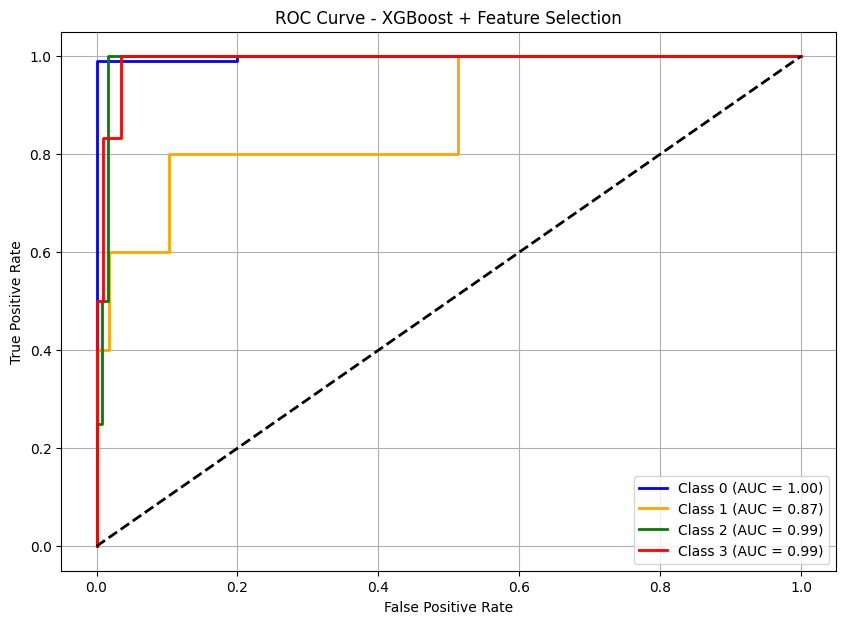

In [32]:
# Prediksi probabilitas
y_score = fs_pipeline.predict_proba(X_test)

# Binarisasi label
y_test_bin = label_binarize(y_test, classes=updated_classes)
n_classes = y_test_bin.shape[1]

# Hitung ROC dan AUC tiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
colors = cycle(['blue', 'orange', 'green', 'red'])
plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost + Feature Selection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [33]:
# Model 3: XGBoost + FS + Hyperparameter Tuning
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.01, 0.1],
    'clf__subsample': [0.8, 1.0]
}
tuned_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('select', SelectKBest(score_func=f_classif, k=10)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])
grid = GridSearchCV(tuned_pipeline, param_grid=param_grid,
                    cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
results.append(evaluate_model("XGBoost Tuned + FS", grid.best_estimator_, X_test, y_test, updated_classes))



Fitting 5 folds for each of 16 candidates, totalling 80 fits
\n==== XGBoost Tuned + FS ====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       107
           1       0.67      0.40      0.50         5
           2       0.67      1.00      0.80         4
           3       0.83      0.83      0.83         6

    accuracy                           0.96       122
   macro avg       0.79      0.81      0.78       122
weighted avg       0.96      0.96      0.96       122

ROC AUC (macro): 0.9598762604394798


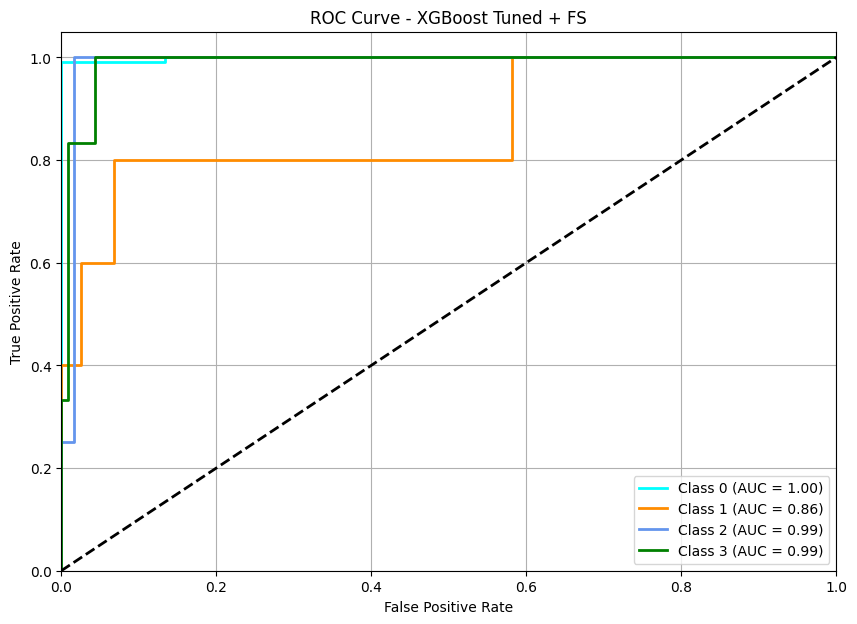

In [34]:
# Ambil model terbaik hasil GridSearchCV
model = grid.best_estimator_

# Prediksi probabilitas untuk ROC Curve
y_score = model.predict_proba(X_test)

# Binarisasi label aktual
y_test_bin = label_binarize(y_test, classes=updated_classes)
n_classes = y_test_bin.shape[1]

# Hitung ROC dan AUC untuk tiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Visualisasi ROC Curve
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
plt.figure(figsize=(10, 7))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:0.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Tuned + FS')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [35]:
# Results
results_df = pd.DataFrame(results)
print("\\n\\n==== Performance Comparison ====")
print(results_df.sort_values(by='F1', ascending=False))

\n\n==== Performance Comparison ====
                Model  Accuracy  Precision    Recall        F1   ROC AUC
2  XGBoost Tuned + FS  0.959016   0.789330  0.805997  0.780997  0.959876
0        XGBoost Base  0.950820   0.730997  0.743497  0.733775  0.969549
1        XGBoost + FS  0.950820   0.730997  0.743497  0.733775  0.963105


In [36]:
# Results dalam persen (dibulatkan)
results_df = pd.DataFrame(results)

# ubah ke persen bulat
results_percent = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']:
    results_percent[col] = (results_percent[col] * 100).round().astype(int).astype(str) + "%"

print("\n\n==== Performance Comparison (dalam Persen) ====")
print(results_percent.sort_values(by='F1', ascending=False))




==== Performance Comparison (dalam Persen) ====
                Model Accuracy Precision Recall   F1 ROC AUC
2  XGBoost Tuned + FS      96%       79%    81%  78%     96%
0        XGBoost Base      95%       73%    74%  73%     97%
1        XGBoost + FS      95%       73%    74%  73%     96%


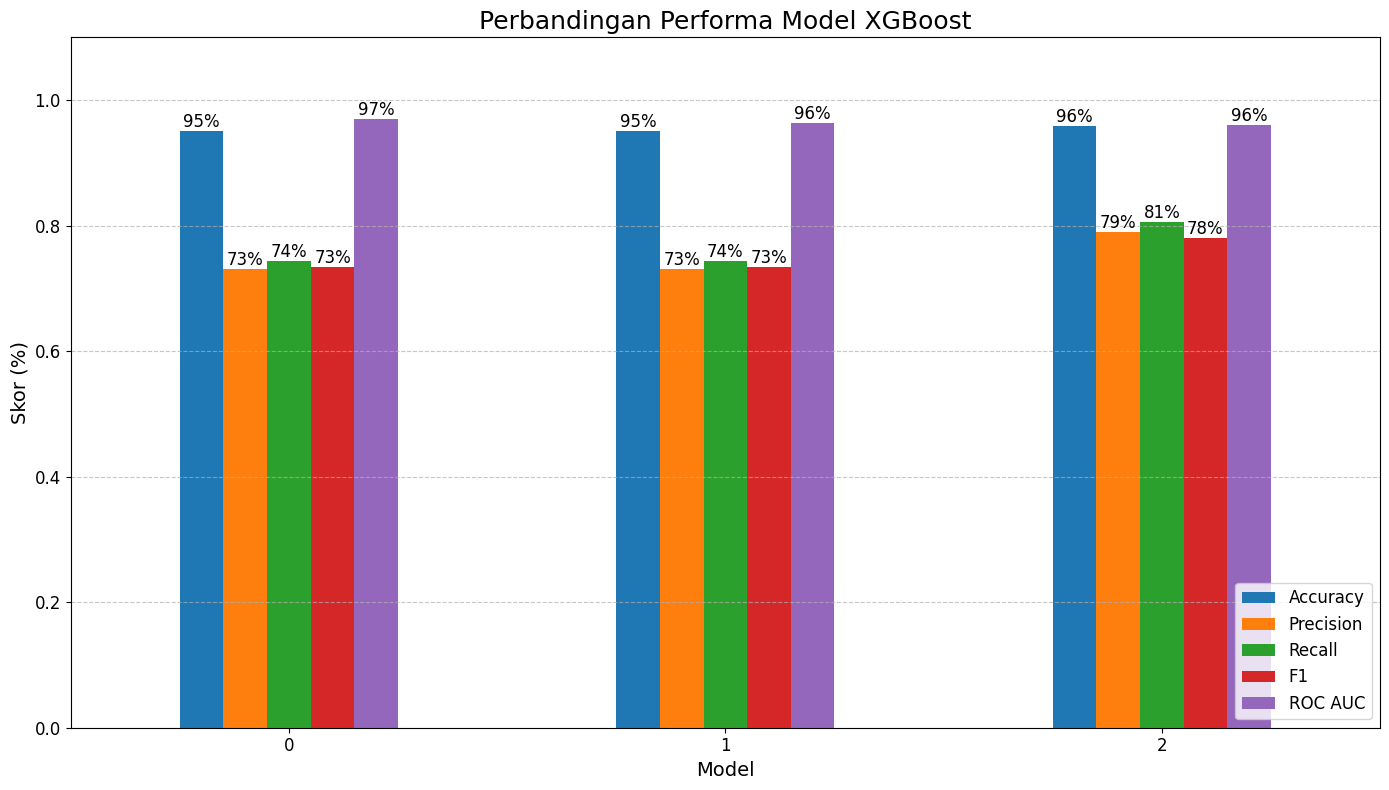

In [37]:
# Visualisasi
ax = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']].plot(
    kind='bar', figsize=(14, 8)
)

plt.title("Perbandingan Performa Model XGBoost", fontsize=18)
plt.ylabel("Skor (%)", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=0, fontsize=12)   # font label bawah
plt.yticks(fontsize=12)               # font angka sumbu Y

# Legend di dalam tapi taruh kanan bawah supaya tidak nutupin bar
plt.legend(
    loc='lower right',
    bbox_to_anchor=(1, 0),
    fontsize=12
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Tambahkan value persentase bulat di atas bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height() * 100:.0f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12, color='black'
    )

plt.show()


<Figure size 600x500 with 0 Axes>

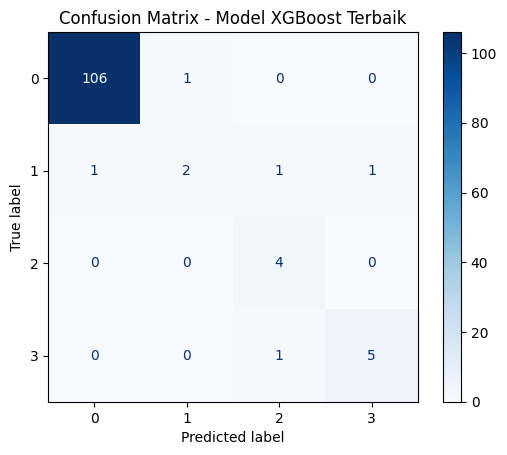

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix untuk model terbaik
y_pred = grid.best_estimator_.predict(X_test)

#Menghitung confusion matrix dari label asli dan prediksi
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')  # angka integer
plt.title("Confusion Matrix - Model XGBoost Terbaik")
plt.show()

In [39]:
# Buat ulang selector
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported if not already

# Inisialisasi imputer dan scaler
imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

# Mengisi missing value pada X_train
X_train_imputed = imputer.fit_transform(X_train)

# standarisasi fitur hasil imputer
X_train_processed = scaler.fit_transform(X_train_imputed)

# Konversi kembali ke DataFrame untuk menjaga nama kolom jika diperlukan,
# atau jika SelectKBest butuh nama kolom (meskipun tidak selalu)
# X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns)


selector = SelectKBest(score_func=f_classif, k=10)
# melatih SelectKBest pada data yang sudah diproses (diimputasi dan diskalakan)
selector.fit(X_train_processed, y_train)

#ambil indeks fitur terpilih
selected_indices = selector.get_support(indices=True)
#ambil nama fitur sesuai indeks terpilih
selected_features = X_train.columns[selected_indices]


print("Fitur yang terpilih oleh SelectKBest:")
print(selected_features.tolist())

Fitur yang terpilih oleh SelectKBest:
['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT']


## Download Model Terbaik

Anda dapat mengunduh model terbaik (`XGBoost Tuned + FS`) dengan menjalankan sel kode di bawah ini. Model akan disimpan dalam format `.pkl`.

In [41]:
import pickle

# Ambil model terbaik dari hasil GridSearchCV
best_model = grid.best_estimator_

# Simpan model ke file .pkl
model_filename = 'xgboost_tuned_fs_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"Model terbaik berhasil disimpan sebagai '{model_filename}'")
print("Anda dapat mengunduh file ini dari sisi kiri panel Colab.")

Model terbaik berhasil disimpan sebagai 'xgboost_tuned_fs_model.pkl'
Anda dapat mengunduh file ini dari sisi kiri panel Colab.
